In [1]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
from jax import jit, vmap
from jax import jacfwd, jacrev
from jax.scipy.stats import multivariate_normal
from functions import F_P, GradientKernel,KernelGradientDiscrepancy
import jax_kernels as ker
from variational_inference import VariationalInference
import functions as f

import jax
from jax import random

In [2]:
device_name = "cpu"

In [3]:
c = 1
def k(x,y):
    return 1/jnp.sqrt((c + jnp.dot(x-y,x-y)))

def q_0(x):
    return jnp.exp(-jnp.linalg.norm(x)**2/2) #/ jnp.sqrt((2 *jnp.pi)**d)

def v(X):
    return -1/4 * jnp.linalg.norm(X, axis=1)**2 

def L(X):
    return jnp.mean(v(X))

k = jit(k)
q_0 = jit(q_0)
v = jit(v)
L = jit(L)


In [ ]:
#eta = 0.1
T = 3000
d = 2

VI = VariationalInference(q_0,L,k,d,[3],"tanh")

# theta0 = flat_params
W0 = random.normal(random.PRNGKey(2), (1000, d))
#X0 = VI.model(Theta[0], W0)

key = random.PRNGKey(1)
Theta,_ = VI.run(T,key)
theta_fin = Theta[-1]

W_fin = random.normal(random.PRNGKey(2), (100, d))
X_fin = vmap(lambda w : VI.model_T(w))(W_fin)
#X = [VI.push_T_theta(theta, W0) for theta in Theta]

In [ ]:
# F_P = f.F_P(q_0, L)
# k_pq = f.GradientKernel(VI.S_PQ,k)
# KGD = f.KernelGradientDiscrepancy(k_pq)

# KGD_fin = jnp.zeros(T)
# # # KDE_KGD_fin = jax.device_put(jnp.zeros(len(Eta)), device)
# # # F_P_fin = jax.device_put(jnp.zeros(len(Eta)), device)
# # # L_fin = jax.device_put(jnp.zeros(len(Eta)), device)

# for it in range(T):
#     KGD_fin = KGD_fin.at[it].set(KGD.evaluate(X[it]))
# #     # KDE_KGD_fin = KDE_KGD_fin.at[e].set(KGD.kde_KGD(X,num_samples = 300))
# #     # F_P_fin = F_P_fin.at[e].set(F_P.evaluate(X,num_samples = 300))
# #     # L_fin = L_fin.at[e].set(L(X))
    

In [ ]:
# plt.plot(KGD_fin)

/var/folders/zl/0c18q_l567xgnm85cwp5t7xm0000gp/T/ipykernel_3049/3605247608.py:38: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(X, Y, Z, levels=10, cmap='viridis', alpha=0.7, label='Gaussian contours')


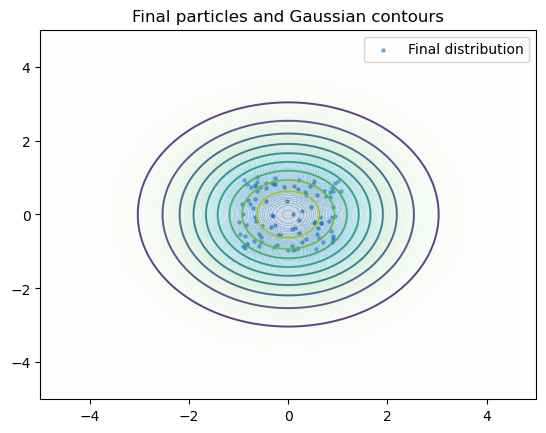

In [ ]:
plt.scatter(X_fin[:, 0], X_fin[:, 1], s=5, alpha=0.5,label='Final distribution')
#plt.scatter(X0[:, 0], X0[:, 1], s=1, alpha=0.5,label = 'Initial distribution')
plt.legend()

import matplotlib.pyplot as plt
import jax.numpy as jnp
from jax.scipy.stats import multivariate_normal

# Paramètres de la distribution
mean = jnp.zeros(2)  # Moyenne (0, 0)
cov = jnp.eye(2) * 2.0  # Matrice de covariance (2 * identité)

# Grille pour les lignes de niveau
x = jnp.linspace(-5, 5, 100)
y = jnp.linspace(-5, 5, 100)
X, Y = jnp.meshgrid(x, y)
pos = jnp.dstack((X, Y))
Z = multivariate_normal.pdf(pos, mean=mean, cov=cov)

cf = plt.contourf(
        X, Y, Z, 
        levels=100,          # plus de niveaux pour un dégradé lisse
        cmap='GnBu', 
        alpha=0.2     # transparence du fond
    )

  # Lignes de contour par-dessus
plt.contour(
    X, Y, Z, 
    levels=10, 
    colors='black', 
    linewidths=0.8,
    alpha=0.5)
# Calcul de la densité de probabilité
Z = multivariate_normal.pdf(pos, mean, cov)

# 
plt.contour(X, Y, Z, levels=10, cmap='viridis', alpha=0.7, label='Gaussian contours')
plt.title("Final particles and Gaussian contours")
plt.legend()
plt.show()

# 4 MFNN 
Here we consider random variables linked by the relation $y,z \in \mathbb{R}$ .$y = sin(z) + \varepsilon$ where $\varepsilon$ is a gaussian noise. Consider $N$ observations pf $(z,y)$, $(Z_1,Y_1),...,(Z_N,Y_N)$. $\mathcal{L} (Q) = \frac1N \sum_{i=1}^N (Y_i - \mathbb{E}_{X \sim Q} [\psi(X,Z)])^2$. The learning function $\psi$ is a two layer neural network with parameter $X$. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
#from mfld import MeanFieldLangevinDynamics
import jax_kernels as ker
import functions as f
import time
from variational_inference import VariationalInference

import jax.numpy as jnp
from jax import jit, vmap
from jax import jacfwd, jacrev
from jax.scipy.stats import multivariate_normal
import random
import jax
from jax import random

from jax.flatten_util import ravel_pytree
from jax import grad, random,vmap,tree_util

In [2]:
device_name = "cpu"

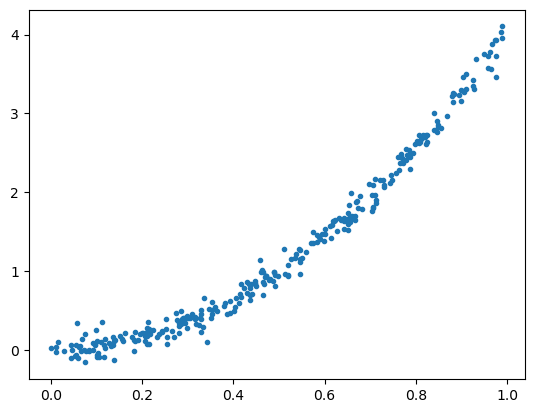

In [22]:

def generate_data(key, s, N, noise_std=0.1):
    key_z, key_noise = random.split(key)
    
    Z = random.uniform(key_z, (N, s),minval = 0,maxval=1.0)  # uniform distribution [-1,1]

    #explanation function
    def f(z):
        return (z*2)**2 #jnp.sin(2 * jnp.pi * z[:,0])#, 0]) + 0.5 * Z[:, 1]**2 - jnp.exp(-Z[:, 2])

    Y_clean = f(Z)

    # noise
    noise = noise_std * random.normal(key_noise, shape=Y_clean.shape)
    Y= Y_clean + noise

    return Z, Y

N = 300
s=1 #input dimension 
key_data = random.PRNGKey(8)
Z,Y = generate_data(key_data,s, N, noise_std=0.1) # put more noise
plt.plot(Z,Y,".")


In [23]:
kernel_name = "IMQ"
c = jnp.array(1.0)
b = 1/2
ell = 2.0
def k(x,y):
    return (c**2 + (x-y).dot(x-y)/ell)**(-b)
    #return jnp.dot(x,y)
# scale = 1
# k = lambda x, y: jnp.exp(-((x-y).dot(x-y)/scale**2))

def q_0(x):
    d = jax.lax.stop_gradient(len(x))
    return jnp.exp(-jnp.dot(x,x)/(2*4)) #/ jnp.sqrt((2 * jnp.pi)**d)


def esp_forward(X, z):
    E = jnp.mean(jit(vmap(lambda x : model.apply(unravel_fn(x), z)))(X))
    return E
gamma = 1000
def L(X):  
    n = len(X)
    Esp_forward = vmap(lambda z: esp_forward(X, z))(Z)  
    return gamma * jnp.mean((Esp_forward - Y) ** 2) 


key = random.PRNGKey(0)
hidden_dim = 1
model = f.MLP(hidden_dims=[hidden_dim], output_dim=1)

params = model.init(key, jnp.ones((s,)))  
flat_params, unravel_fn = ravel_pytree(params)
d = len(flat_params)  


k = jit(k)
q_0 = jit(q_0)
esp_forward = jit(esp_forward)
L = jit(L)  
 
learning_rate = 1e-5
VI = VariationalInference(q_0, L, k, d,[20,20,20],"elu", learning_rate) 

In [24]:
T = 1000
n = 100


key = random.PRNGKey(1)
Theta,Loss,positions = VI.run(T,key,1000)
theta_fin = Theta[-1]

W_fin = random.uniform(random.PRNGKey(2), shape=(n, 4),minval = -7.0,maxval=7.0)#random.normal(random.PRNGKey(2), (n, d))
X_fin = vmap(lambda w : VI.model_T(w))(W_fin)
XX_fin = positions[-1]

0


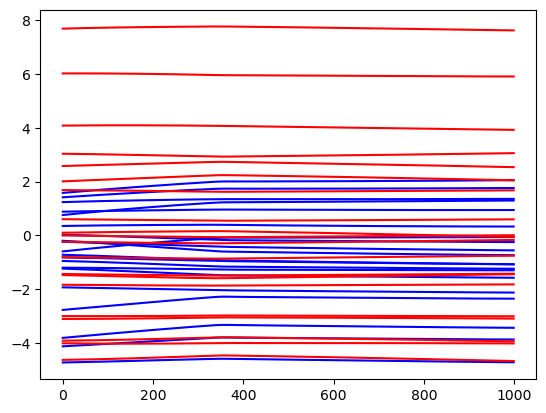

In [25]:
positions = jnp.array(positions)
plt.plot(positions[:,:20,0],color = "blue")
plt.plot(positions[:,:20,1],color = "red")

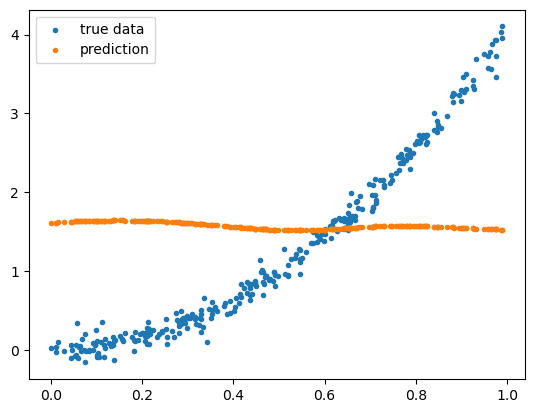

In [26]:
plt.figure()
plt.scatter(Z,Y,label = "true data",marker = ".")
Y_hat = vmap(lambda z : esp_forward(X_fin, z))(Z)
plt.scatter(Z,Y_hat,label = "prediction",marker = ".")
plt.legend()



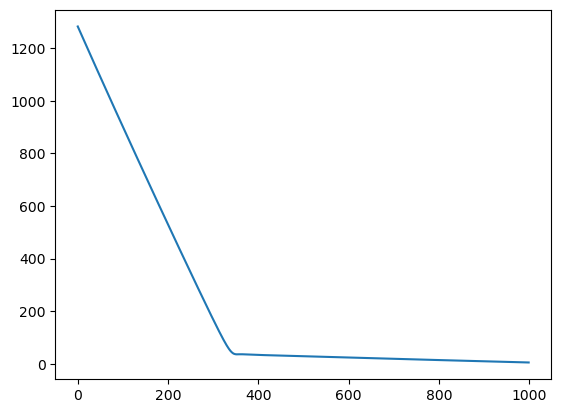

In [27]:
plt.plot(Loss[:])

In [28]:
F_P = f.F_P(q_0, L)
k_pq = f.GradientKernel(VI.S_PQ,k)
KGD = f.KernelGradientDiscrepancy(k_pq)

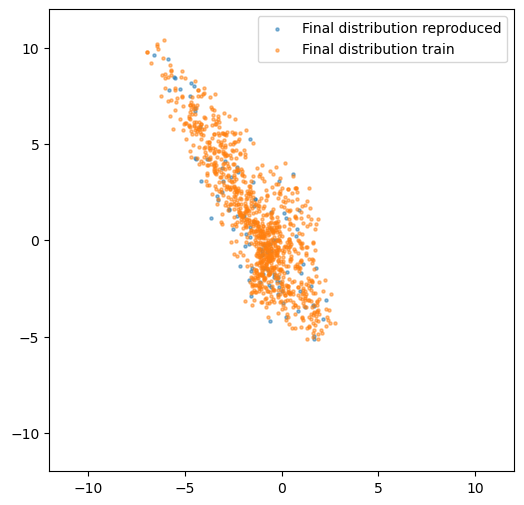

In [29]:
plt.figure(figsize=(6, 6))
plt.scatter(X_fin[:, 0], X_fin[:, 1], s=5, alpha=0.5,label='Final distribution reproduced')
plt.scatter(XX_fin[:, 0], XX_fin[:, 1], s=5, alpha=0.5,label='Final distribution train')
plt.axis([-12,12,-12,12])
plt.legend()

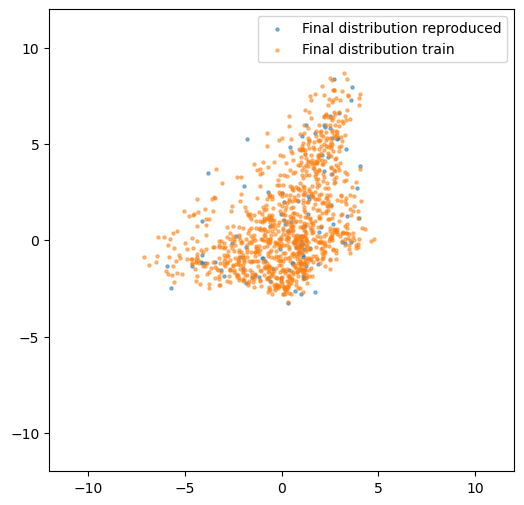

In [18]:
plt.figure(figsize=(6, 6))
plt.scatter(X_fin[:, 2], X_fin[:, 3], s=5, alpha=0.5,label='Final distribution reproduced')
plt.scatter(XX_fin[:, 2], XX_fin[:, 3], s=5, alpha=0.5,label='Final distribution train')
plt.axis([-12,12,-12,12])
plt.legend()